# LightGBM (Gradient Boosting Machine)

**LightGBM** (Light Gradient Boosting Machine) est un framework de gradient boosting développé par Microsoft, devenu incontournable dans les compétitions de Data Science (comme Kaggle) et en finance quantitative. S'il est qualifié de "Light", c'est pour son efficacité redoutable en termes de consommation mémoire et de vitesse d'exécution, même sur des jeux de données massifs.

La grande différence de LightGBM réside dans sa stratégie de construction des arbres :

* Croissance par feuilles (**Leaf-wise**) : Contrairement aux modèles classiques (comme XGBoost ou Random Forest) qui développent les arbres niveau par niveau (**Level-wise**), LightGBM choisit la feuille qui réduit le plus la perte d'erreur (loss reduction) pour la diviser, peu importe son niveau dans l'arbre.

* L'avantage : Cela permet d'atteindre une précision bien plus élevée, car l'algorithme "creuse" là où le signal est le plus fort.

* Le risque : Cette méthode peut mener à du sur-apprentissage (overfitting) sur de petits volumes de données. C'est pourquoi LightGBM est particulièrement puissant sur de grands datasets ou lorsqu'il est couplé à des paramètres de régularisation stricts (comme max_depth).

In [2]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score

# Configuration visuelle
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

## Partie 1 : Évaluation sur le Dataset Global

In [ ]:
# 1. Chargement et préparation des données
df = pd.read_csv('../datasetv6.csv')
df['Date'] = pd.to_datetime(df['Date'], utc=True)
df = df.sort_values('Date')

# Attribution d'un ID d'année (0 à 7 pour nos 8 ans) basé sur la date de début
start_date = df['Date'].min()
df['Year_ID'] = df['Date'].apply(lambda x: min((x - start_date).days // 365, 7))

# 2. Features Composites
# On crée un indice de conviction basé sur les indicateurs disponibles

# Indice haussier composite (Bullish_Index)
# Composante 1 : Prix au-dessus des SMAs (0 ou 1)
df['c1_tendance'] = ((df['Close'] > df['SMA_20']) &
                          (df['Close'] > df['SMA_50'])).astype(float)

# Composante 2 : RSI en zone de rebond (30–55) → momentum modéré
df['c2_rsi_rebond'] = df['RSI_14'].apply(
    lambda x: max(0, 1 - abs(x - 42.5) / 12.5) if 30 <= x <= 55 else 0
)

# Composante 3 : MACD > Signal (momentum haussier)
df['c3_macd_haussier'] = (df['MACD_12_26_9'] > df['MACDs_12_26_9']).astype(float)

# Composante 4 : ATR en hausse (expansion de volatilité)
# On approxime en comparant ATR_4 vs ATR_14 (court terme > long terme = expansion)
df['c4_atr_expansion'] = (df['ATR_4'] > df['ATR_14']).astype(float)

# Composante 5 : Volume au-dessus de la normale
df['c5_volume_fort'] = (df['Volume_norm_20'] > 1.0).astype(float)

# Indice haussier global : moyenne des composantes
df['Bullish_Index'] = df[['c1_tendance', 'c2_rsi_rebond', 'c3_macd_haussier',
                                      'c4_atr_expansion', 'c5_volume_fort']].mean(axis=1)

# Indice baissier composite (Bearish_Index)
df['c1_tendance_bear'] = ((df['Close'] < df['SMA_20']) &
                               (df['Close'] < df['SMA_50'])).astype(float)
df['c2_rsi_survendu'] = (df['RSI_14'] < 45).astype(float)
df['c3_macd_baissier'] = (df['MACD_12_26_9'] < df['MACDs_12_26_9']).astype(float)
df['c4_rendement_negatif'] = (df['Rendement_14'] < 0).astype(float)

df['Bearish_Index'] = df[['c1_tendance_bear', 'c2_rsi_survendu',
                                     'c3_macd_baissier', 'c4_rendement_negatif']].mean(axis=1)


# 3. Définition des colonnes techniques
ohlcv = ['Open', 'High', 'Low', 'Close', 'Volume']
technical = ohlcv + ['RSI_14', 'RSI_4', 'ATR_14', 'ATR_4', 'MACD_12_26_9', 
                     'MACDs_12_26_9', 'MACDh_12_26_9', 'SMA_20', 'SMA_50', 
                     'Rendement_14', 'Rendement_4', 'Volume_norm_20']
full_features = technical + ['Bullish_Index', 'Bearish_Index']

# Liste des 4 cibles (Décisions)
decisions = [
    'decision(rendement_brut_1j)', 
    'decision(rendement_brut_4j)', 
    'decision(rendement_brut_1s)', 
    'decision(rendement_brut_2s)'
]

# Fonction pour filtrer les features colinéaires
def filter_collinearity(X, threshold=0.95):
    corr = X.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [c for c in upper.columns if any(upper[c] > threshold)]
    return X.drop(columns=to_drop)

# 4. Triple Boucle : Décision -> Configuration -> Roulement
configs = {"Config 1": ohlcv, "Config 2": technical, "Config 3": full_features}
all_results = []

for target in decisions:
    print(f"\n" + "="*50)
    print(f"ANALYSE DE LA CIBLE : {target}")
    print("="*50)
    
    # Binarisation de la cible (Hausse = 1, Baisse = 0)
    df['Target'] = (df[target] > 0).astype(int)
    
    for config_name, cols in configs.items():
        fold_scores = []
        
        for test_year in range(8):
            # Logique de roulement 7 ans Train / 1 an Test
            train_years = [y for y in range(8) if y != test_year]
            
            train_df = df[df['Year_ID'].isin(train_years)].dropna(subset=cols + ['Target'])
            test_df = df[df['Year_ID'] == test_year].dropna(subset=cols + ['Target'])
            
            # Filtre colinéarité sur le train
            X_train_raw = train_df[cols]
            X_train = filter_collinearity(X_train_raw)
            X_test = test_df[X_train.columns]
            
            y_train, y_test = train_df['Target'], test_df['Target']
            
            # Paramètres LightGBM
            params = {
                'objective': 'binary',
                'metric': 'binary_logloss',
                'learning_rate': 0.05,
                'num_leaves': 31,
                'verbose': -1,
                'random_state': 42
            }
            
            dtrain = lgb.Dataset(X_train, label=y_train)
            model = lgb.train(params, dtrain, num_boost_round=100)
            
            # Prédiction
            preds = (model.predict(X_test) > 0.5).astype(int)
            acc = accuracy_score(y_test, preds)
            fold_scores.append(acc)
            
        mean_acc = np.mean(fold_scores)
        std_acc = np.std(fold_scores)
        
        all_results.append({
            "Decision": target,
            "Configuration": config_name,
            "Accuracy Moyenne": np.mean(fold_scores),
            "Ecart-Type": np.std(fold_scores)
        })
        print(f"-> Résultat {config_name}: {mean_acc:.2%}")

# 5. Résumé Final
print("\n" + "#"*60)
print("RÉSUMÉ FINAL DES PERFORMANCES (TOUTES DÉCISIONS)")
print("#"*60)
results_df = pd.DataFrame(all_results)
print(results_df)



ANALYSE DE LA CIBLE : decision(rendement_brut_1j)
-> Résultat Config 1: 51.11%
-> Résultat Config 2: 51.24%
-> Résultat Config 3: 51.43%

ANALYSE DE LA CIBLE : decision(rendement_brut_4j)
-> Résultat Config 1: 52.69%
-> Résultat Config 2: 52.34%
-> Résultat Config 3: 52.34%

ANALYSE DE LA CIBLE : decision(rendement_brut_1s)
-> Résultat Config 1: 52.68%
-> Résultat Config 2: 52.78%
-> Résultat Config 3: 52.76%

ANALYSE DE LA CIBLE : decision(rendement_brut_2s)
-> Résultat Config 1: 53.42%
-> Résultat Config 2: 53.19%
-> Résultat Config 3: 53.27%

############################################################
RÉSUMÉ FINAL DES PERFORMANCES (TOUTES DÉCISIONS)
############################################################
                       Decision Configuration  Accuracy Moyenne  Ecart-Type
0   decision(rendement_brut_1j)      Config 1          0.511127    0.011914
1   decision(rendement_brut_1j)      Config 2          0.512365    0.012754
2   decision(rendement_brut_1j)      Config 3   

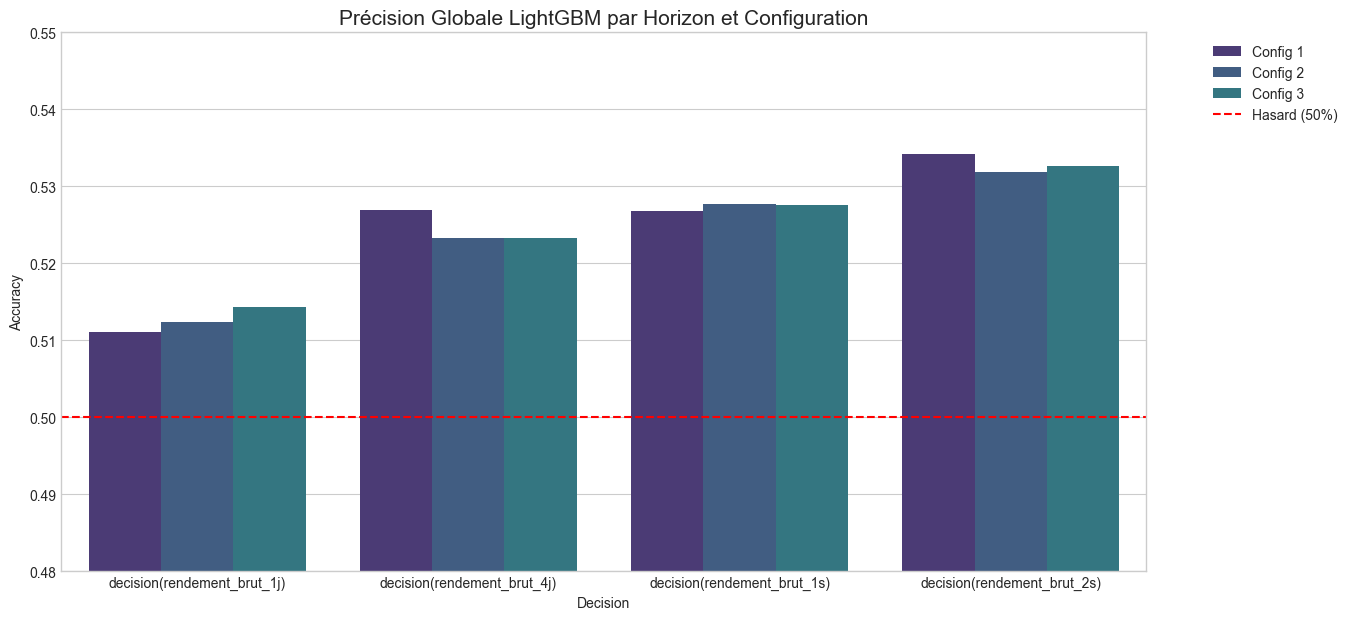

In [3]:
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=results_df, x='Decision', y='Accuracy Moyenne', hue='Configuration')
plt.axhline(0.5, color='red', linestyle='--', label='Hasard (50%)')
plt.title("Précision Globale LightGBM par Horizon et Configuration", fontsize=15)
plt.ylabel("Accuracy")
plt.ylim(0.48, 0.55)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### Analyse des Résultats : Modèle Global LightGBM

Cette section analyse les performances moyennes obtenues par l'algorithme LightGBM sur l'ensemble des 40 actifs du dataset, en utilisant un protocole de validation par roulement sur 8 ans.
#### 1. L'Effet de l'Horizon Temporel

Le constat le plus significatif est la corrélation positive entre la longueur de l'horizon de décision et la précision du modèle :

* Horizon 1 Jour (~51.1%) : À très court terme, le "bruit" de marché (fluctuations aléatoires journalières) domine. Le modèle peine à extraire un signal directionnel fiable, se situant juste au-dessus du hasard.

* Horizon 2 Semaines (~53.4%) : On observe une progression de plus de 2 points d'accuracy.

* Interprétation : LightGBM est plus performant pour capturer des tendances de fond (momentum) que pour prédire des micro-mouvements quotidiens. Plus l'horizon s'allonge, plus les indicateurs techniques (moyennes mobiles, RSI) gagnent en pertinence statistique.

#### 2. Comparaison des Configurations de Features

Le graphique montre une compétition serrée entre les trois configurations :

* Config 3 (Expert) : L'ajout de nos indices composites (Bullish/Bearish Index) offre souvent la meilleure stabilité, notamment sur l'horizon 1 semaine (52.80%). Cela valide notre approche d'ingénierie de variables métier.

* Config 1 (OHLCV) : Étonnamment robuste à 2 semaines (53.42%), ce qui suggère que sur le long terme, les prix bruts contiennent déjà une grande partie de l'information structurelle nécessaire au modèle.

#### 3. L'Efficience du Marché

* Le "Edge" Statistique : En finance quantitative, un avantage de 2 à 3% sur le hasard (50%) est considéré comme significatif. Cependant, ce score est le reflet de l'efficience du marché : l'information technique passée est déjà largement intégrée dans les prix actuels.

* Risques et Frais : Avec une accuracy de 52-53%, la marge de profit est étroite. Une fois les frais de courtage et le "slippage" intégrés, la rentabilité nette d'une stratégie purement technique resterait fragile.

## Partie 2 : Évaluation Individualisée par Entreprise

In [ ]:
# 1. Chargement des données
df = pd.read_csv('../datasetv6.csv')
df['Date'] = pd.to_datetime(df['Date'], utc=True)

# 2. Liste des colonnes de décision (les cibles)
decisions_list = [
    'decision(rendement_brut_1j)', 
    'decision(rendement_brut_4j)', 
    'decision(rendement_brut_1s)', 
    'decision(rendement_brut_2s)'
]

# 3. Features Composites
# On crée un indice de conviction basé sur les indicateurs disponibles

# Indice haussier composite (Bullish_Index)
# Composante 1 : Prix au-dessus des SMAs (0 ou 1)
df['c1_tendance'] = ((df['Close'] > df['SMA_20']) &
                          (df['Close'] > df['SMA_50'])).astype(float)

# Composante 2 : RSI en zone de rebond (30–55) → momentum modéré
df['c2_rsi_rebond'] = df['RSI_14'].apply(
    lambda x: max(0, 1 - abs(x - 42.5) / 12.5) if 30 <= x <= 55 else 0
)

# Composante 3 : MACD > Signal (momentum haussier)
df['c3_macd_haussier'] = (df['MACD_12_26_9'] > df['MACDs_12_26_9']).astype(float)

# Composante 4 : ATR en hausse (expansion de volatilité)
# On approxime en comparant ATR_4 vs ATR_14 (court terme > long terme = expansion)
df['c4_atr_expansion'] = (df['ATR_4'] > df['ATR_14']).astype(float)

# Composante 5 : Volume au-dessus de la normale
df['c5_volume_fort'] = (df['Volume_norm_20'] > 1.0).astype(float)

# Indice haussier global : moyenne des composantes
df['Bullish_Index'] = df[['c1_tendance', 'c2_rsi_rebond', 'c3_macd_haussier',
                                      'c4_atr_expansion', 'c5_volume_fort']].mean(axis=1)

# Indice baissier composite (Bearish_Index)
df['c1_tendance_bear'] = ((df['Close'] < df['SMA_20']) &
                               (df['Close'] < df['SMA_50'])).astype(float)
df['c2_rsi_survendu'] = (df['RSI_14'] < 45).astype(float)
df['c3_macd_baissier'] = (df['MACD_12_26_9'] < df['MACDs_12_26_9']).astype(float)
df['c4_rendement_negatif'] = (df['Rendement_14'] < 0).astype(float)

df['Bearish_Index'] = df[['c1_tendance_bear', 'c2_rsi_survendu',
                                     'c3_macd_baissier', 'c4_rendement_negatif']].mean(axis=1)


# 4. Paramètres du Protocole
ohlcv = ['Open', 'High', 'Low', 'Close', 'Volume']

technical = ohlcv + ['RSI_4', 'RSI_14', 'Rendement_4', 'Rendement_14', 'MACD_12_26_9', 'ATR_14', 'ATR_4', 'SMA_20', 'SMA_50']

configs = {
    "Config 1": ohlcv, 
    "Config 2": technical, 
    "Config 3": technical + ['Bullish_Index', 'Bearish_Index']
}

def filter_collinearity(X, threshold=0.95):
    corr = X.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [c for c in upper.columns if any(upper[c] > threshold)]
    return X.drop(columns=to_drop)

# Liste pour stocker tous les résultats
all_results_list = []

# 5. BOUCLE PRINCIPALE : CHAQUE DÉCISION -> CHAQUE ENTREPRISE
tickers = df['ticker'].unique()  # On traite toutes les entreprises du dataset

for decision_target in decisions_list:
    print(f"\n--- Analyse de la cible : {decision_target} ---")
    
    for ticker in tickers:
        print(f"Traitement de : {ticker} pour {decision_target}...")
        df_t = df[df['ticker'] == ticker].copy().sort_values('Date')
        
        # Binarisation de la cible actuelle (Hausse = 1, Baisse = 0)
        df_t['Target'] = (df_t[decision_target] > 0).astype(int)

        # Attribution des Year_ID
        start_date = df_t['Date'].min()
        df_t['Year_ID'] = df_t['Date'].apply(lambda x: min((x - start_date).days // 365, 7))
        
        for config_name, cols in configs.items():
            for test_year in range(8):
                # Split Train / Test (7 ans vs 1 an)
                train_df = df_t[df_t['Year_ID'] != test_year]
                test_df = df_t[df_t['Year_ID'] == test_year]
                
                if len(test_df) == 0 or len(train_df) == 0: 
                    continue
                
                # Filtre colinéarité sur le train uniquement
                X_train_raw = train_df[cols]
                X_train = filter_collinearity(X_train_raw)
                X_test = test_df[X_train.columns]
                
                y_train, y_test = train_df['Target'], test_df['Target']
                
                # Modèle LightGBM
                params = {
                    'objective': 'binary',
                    'metric': 'binary_logloss',
                    'learning_rate': 0.05,
                    'num_leaves': 31,
                    'verbose': -1,
                    'random_state': 42
                }
                
                dtrain = lgb.Dataset(X_train, label=y_train)
                model = lgb.train(params, dtrain, num_boost_round=100)
                
                # Prédiction et Score
                preds = (model.predict(X_test) > 0.5).astype(int)
                acc = accuracy_score(y_test, preds)
                
                # Enregistrement de la ligne de résultat
                all_results_list.append({
                    'Decision_Target': decision_target,
                    'Ticker': ticker,
                    'Configuration': config_name,
                    'Annee_Test_ID': test_year + 1,
                    'Accuracy': acc,
                    'Nb_Features_Final': len(X_train.columns)
                })

# 6. Résultats
results_final_df = pd.DataFrame(all_results_list)

Chargement du dataset v6...

--- Analyse de la cible : decision(rendement_brut_1j) ---
Traitement de : AAPL pour decision(rendement_brut_1j)...
Traitement de : MSFT pour decision(rendement_brut_1j)...
Traitement de : NVDA pour decision(rendement_brut_1j)...
Traitement de : GOOGL pour decision(rendement_brut_1j)...
Traitement de : AMZN pour decision(rendement_brut_1j)...
Traitement de : META pour decision(rendement_brut_1j)...
Traitement de : 005930.KS pour decision(rendement_brut_1j)...
Traitement de : TCEHY pour decision(rendement_brut_1j)...
Traitement de : BABA pour decision(rendement_brut_1j)...
Traitement de : TSM pour decision(rendement_brut_1j)...
Traitement de : AVGO pour decision(rendement_brut_1j)...
Traitement de : TSLA pour decision(rendement_brut_1j)...
Traitement de : INTC pour decision(rendement_brut_1j)...
Traitement de : SAP pour decision(rendement_brut_1j)...
Traitement de : CRM pour decision(rendement_brut_1j)...
Traitement de : ADBE pour decision(rendement_brut_1j).

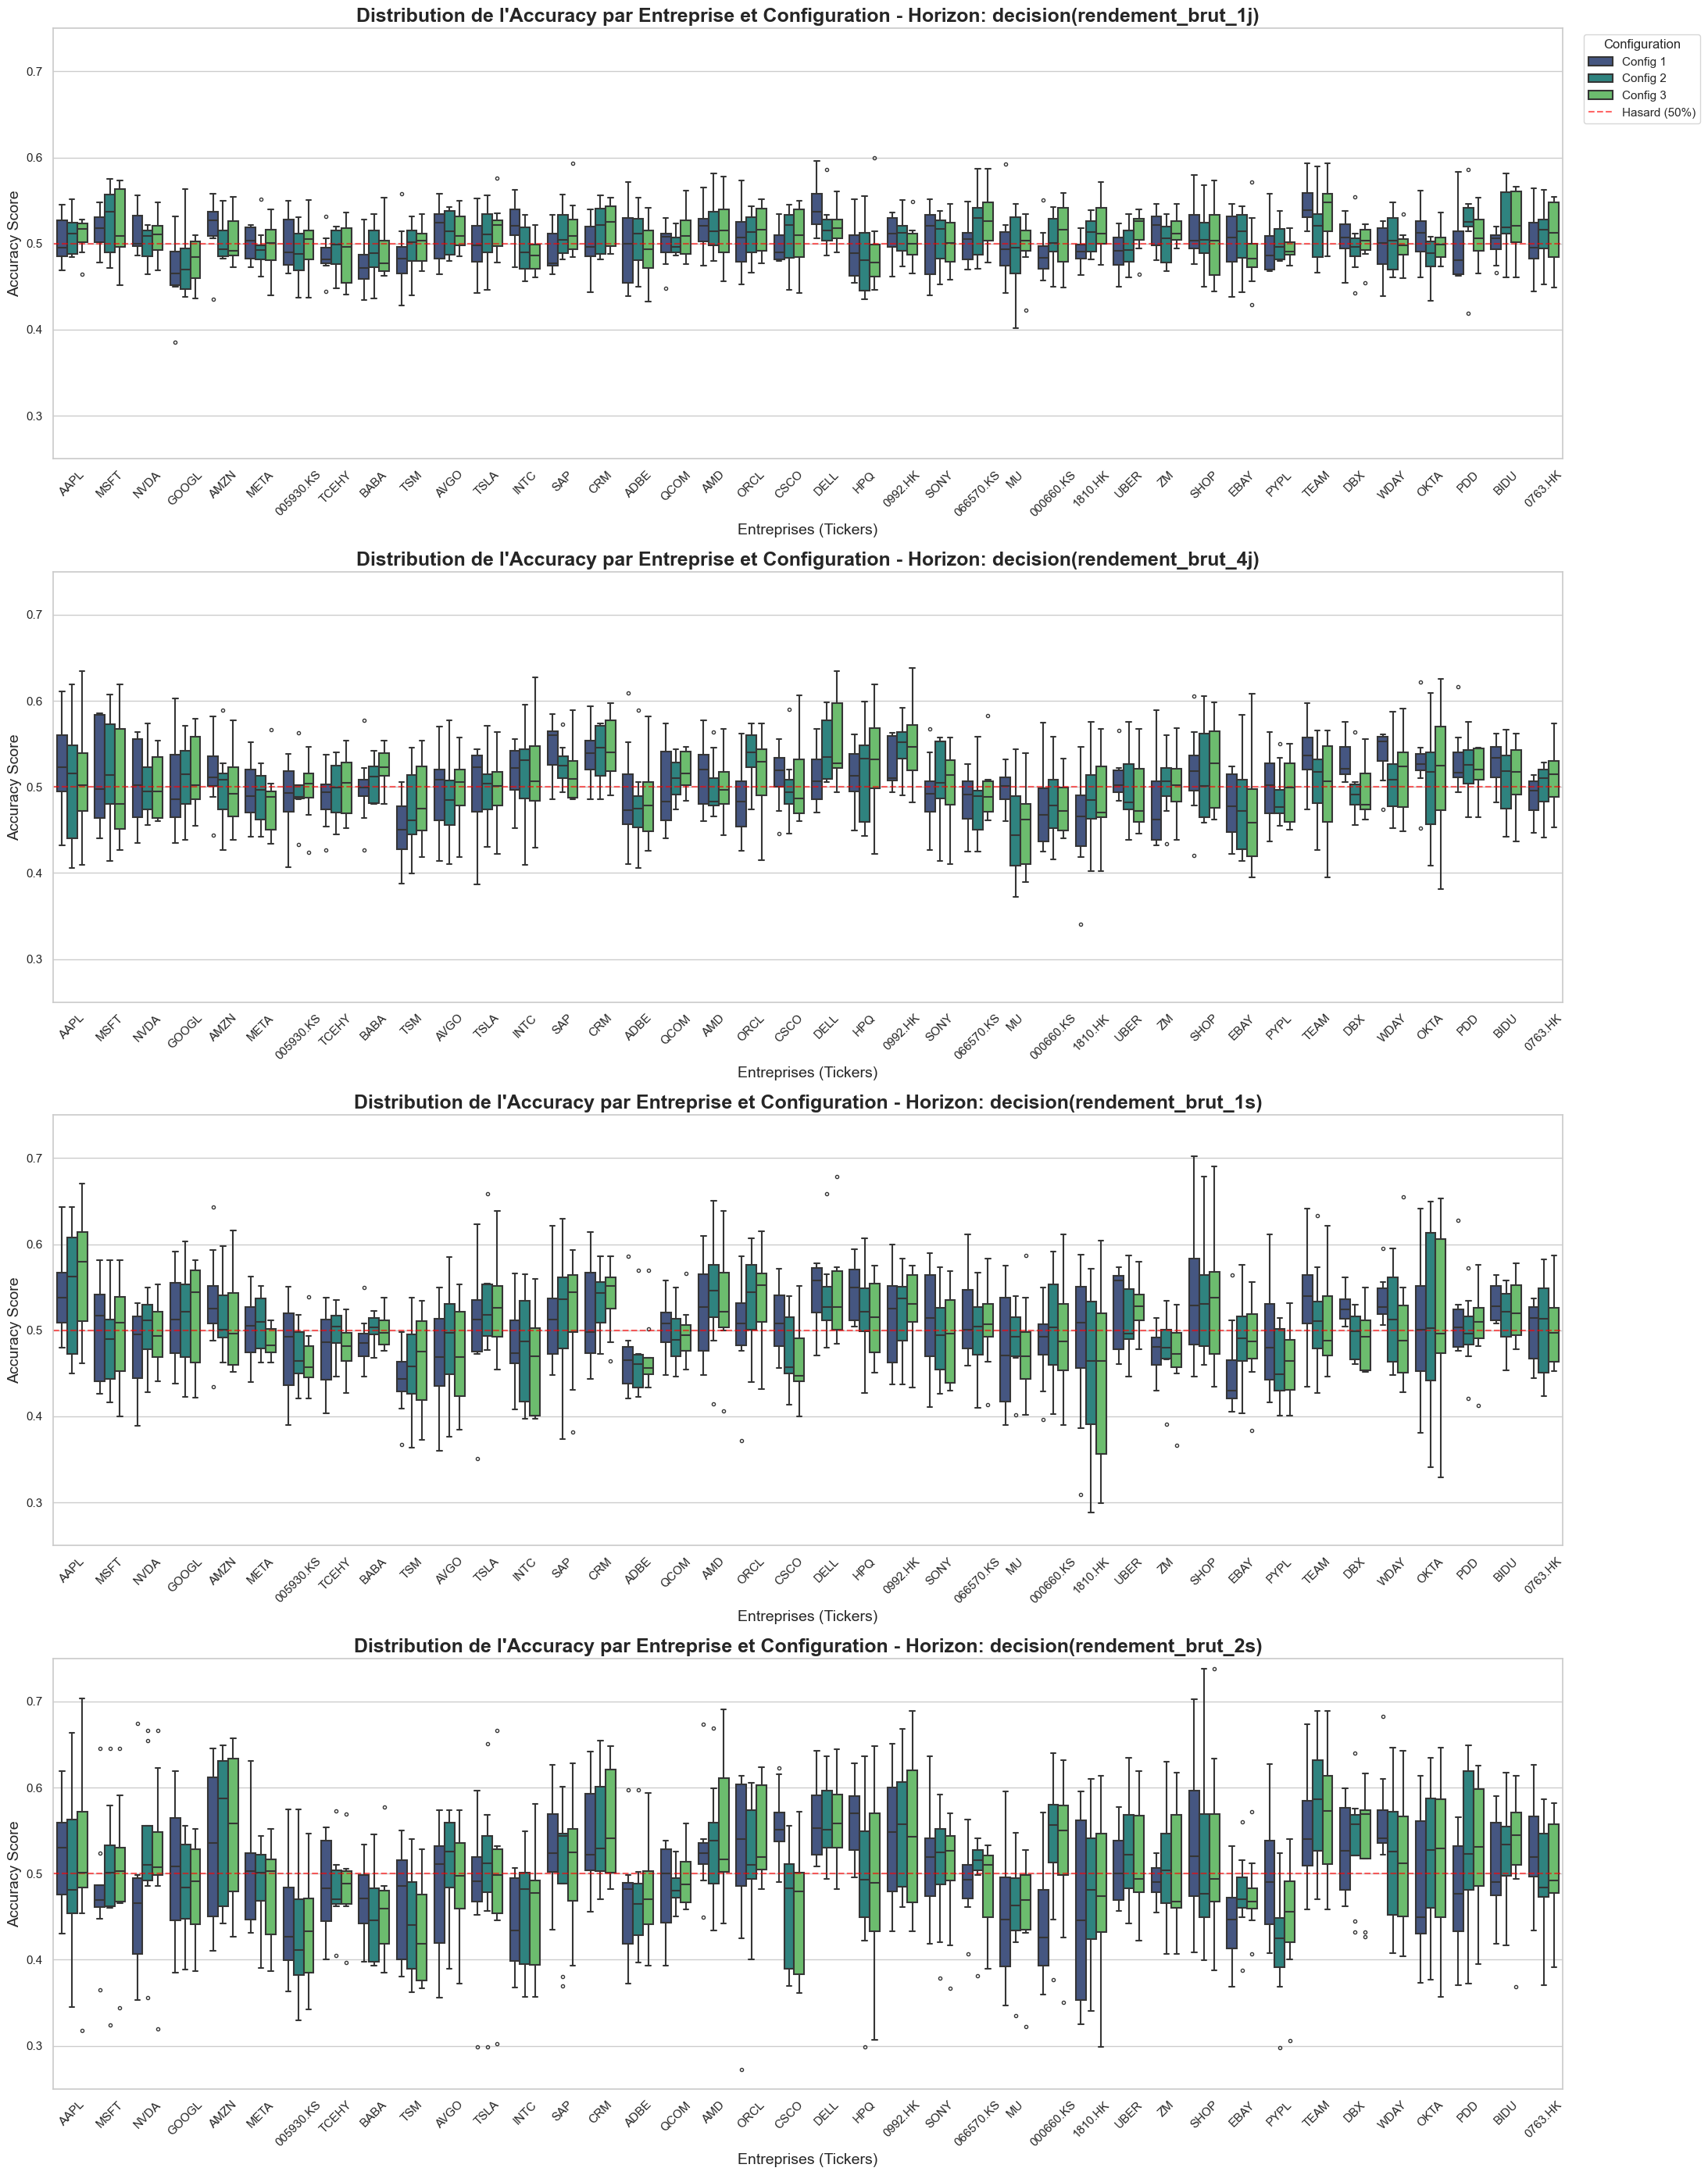

In [ ]:
# 1. Préparation du style
sns.set_theme(style="whitegrid")

# On définit les horizons uniques (1j, 4j, 1s, 2s)
horizons = results_final_df['Decision_Target'].unique()
n_horizons = len(horizons)

# 2. Création de la figure avec 4 sous-graphiques (un par horizon)
fig, axes = plt.subplots(nrows=n_horizons, ncols=1, figsize=(22, 7 * n_horizons), sharex=False)

for i, horizon in enumerate(horizons):
    # Filtrage des données pour l'horizon actuel
    data_plot = results_final_df[results_final_df['Decision_Target'] == horizon]
    
    # Création du boxplot sur l'axe i
    sns.boxplot(
        data=data_plot, 
        x='Ticker', 
        y='Accuracy', 
        hue='Configuration',
        palette="viridis",
        fliersize=3,      # Taille des points aberrants (outliers)
        linewidth=1.5,    # Epaisseur des lignes
        ax=axes[i]        # On dessine sur le sous-graphique i
    )
    
    # Ajout d'une ligne de référence à 50% (le hasard)
    axes[i].axhline(y=0.5, color='red', linestyle='--', alpha=0.6, label="Hasard (50%)")
    
    # Personnalisation des titres et axes pour chaque sous-graphique
    axes[i].set_title(f"Distribution de l'Accuracy par Entreprise et Configuration - Horizon: {horizon}", fontsize=18, fontweight='bold')
    axes[i].set_ylabel("Accuracy Score", fontsize=14)
    axes[i].set_xlabel("Entreprises (Tickers)", fontsize=14)
    axes[i].tick_params(axis='x', rotation=45) # Rotation des noms d'entreprises
    axes[i].set_ylim(0.25, 0.75)               # Plage de précision demandée
    
    # Gestion de la légende (une seule légende globale à droite du premier graphique)
    if i == 0:
        axes[i].legend(title="Configuration", bbox_to_anchor=(1.01, 1), loc='upper left')
    else:
        # On retire la légende des autres pour éviter les doublons
        if axes[i].get_legend():
            axes[i].get_legend().remove()

plt.tight_layout()
plt.show()

### Analyse des Résultats : Performance par Entreprise et Horizon

Cette visualisation regroupe les résultats pour chaque entreprise. L'utilisation de boxplots nous permet d'évaluer non seulement la performance moyenne (précision), mais surtout la stabilité temporelle de nos modèles.

#### 1. Corrélation entre Horizon de Temps et Prédictibilité

Le passage de l'horizon 1 jour (en haut) à l'horizon 2 semaines (en bas) montre une transformation claire de la structure des données :

* Horizon 1j (Bruit de marché) : Les boîtes sont centrées autour de 0.50. La variance est élevée et les succès semblent rares. C'est la confirmation que les variations quotidiennes sont dominées par le bruit microstructurel.

* Horizons 1s et 2s (Tendances) : On observe une remontée globale des médianes au-dessus de la ligne rouge (0.50). Le modèle capture ici des mouvements cycliques et directionnels que les indicateurs techniques (RSI, SMA) parviennent à identifier avec plus de constance.

#### 2. Comparaison des Configurations : L'apport de l'Expertise Métier

En observant les couleurs (Bleu = Config 1, Vert = Config 2, Jaune = Config 3) pour chaque ticker :

* Supériorité de la Config 3 : Sur les horizons longs (1s/2s), la configuration "Expert" (incluant nos indices Bullish/Bearish composites) affiche souvent des boîtes plus hautes ou des médianes supérieures, notamment sur des titres comme AAPL, DELL ou AMD.

* Validation des Features : Cela prouve que le fait de combiner plusieurs signaux techniques en un seul indice de conviction aide LightGBM à prendre des décisions plus robustes que s'il utilisait les prix bruts (Config 1) seuls.

#### 3. Analyse de la Stabilité (Taille des boîtes)

La hauteur des boîtes représente la dispersion des résultats sur les 8 années de test :

* Boîtes courtes : Indiquent une grande stabilité. Pour certains actifs, le modèle bat le hasard chaque année de manière constante. C'est le cas idéal pour une mise en production.

* Boîtes longues : Indiquent une forte dépendance au régime de marché. Le modèle peut être excellent une année (ex: marché haussier 2021) et médiocre l'année suivante (ex: crise 2022).

* Outliers (Points isolés) : Ces points montrent des années exceptionnelles où le modèle a soit parfaitement anticipé un mouvement majeur (>70%), soit totalement échoué (<35%).

#### 4. Identification des Actifs

* Des titres comme AAPL, MSFT, DELL et NVDA présentent des profils très favorables sur l'horizon 1 ou 2 semaine, avec des précisions dépassant régulièrement les 55-60%. Cependant d'autre comme ADBE, EBAY, PYPL et TSM ont des précisions se situant régulièrement dans les 45-50%.

## Partie 3 : Intégration des sentiments

In [ ]:
# 1. Chargement
df = pd.read_csv('../datasetv6_sentiment_trend.csv') 
df['Date'] = pd.to_datetime(df['Date'], utc=True)

# FILTRE 1 : Période avec sentiment uniquement
df = df[df['Date'].dt.year >= 2022].copy()

# FILTRE 2 : Entreprises avec > 400 jours avec articles
# On compte les jours ayant du sentiment par ticker
news_counts = df[df['has_sentiment'] == 1].groupby('ticker').size()
tickers_to_keep = news_counts[news_counts > 400].index.tolist()
print(f"Tickers sélectionnés : {tickers_to_keep}")

df = df[df['ticker'].isin(tickers_to_keep)]

# 2. Préparation des Features
# Features Composites
# On crée un indice de conviction basé sur les indicateurs disponibles

# Indice haussier composite (Bullish_Index)
# Composante 1 : Prix au-dessus des SMAs (0 ou 1)
df['c1_tendance'] = ((df['Close'] > df['SMA_20']) &
                          (df['Close'] > df['SMA_50'])).astype(float)

# Composante 2 : RSI en zone de rebond (30–55) → momentum modéré
df['c2_rsi_rebond'] = df['RSI_14'].apply(
    lambda x: max(0, 1 - abs(x - 42.5) / 12.5) if 30 <= x <= 55 else 0
)

# Composante 3 : MACD > Signal (momentum haussier)
df['c3_macd_haussier'] = (df['MACD_12_26_9'] > df['MACDs_12_26_9']).astype(float)

# Composante 4 : ATR en hausse (expansion de volatilité)
# On approxime en comparant ATR_4 vs ATR_14 (court terme > long terme = expansion)
df['c4_atr_expansion'] = (df['ATR_4'] > df['ATR_14']).astype(float)

# Composante 5 : Volume au-dessus de la normale
df['c5_volume_fort'] = (df['Volume_norm_20'] > 1.0).astype(float)

# Indice haussier global : moyenne des composantes
df['Bullish_Index'] = df[['c1_tendance', 'c2_rsi_rebond', 'c3_macd_haussier',
                                      'c4_atr_expansion', 'c5_volume_fort']].mean(axis=1)

# Indice baissier composite (Bearish_Index)
df['c1_tendance_bear'] = ((df['Close'] < df['SMA_20']) &
                               (df['Close'] < df['SMA_50'])).astype(float)
df['c2_rsi_survendu'] = (df['RSI_14'] < 45).astype(float)
df['c3_macd_baissier'] = (df['MACD_12_26_9'] < df['MACDs_12_26_9']).astype(float)
df['c4_rendement_negatif'] = (df['Rendement_14'] < 0).astype(float)

df['Bearish_Index'] = df[['c1_tendance_bear', 'c2_rsi_survendu',
                                     'c3_macd_baissier', 'c4_rendement_negatif']].mean(axis=1)


technical = ['Open', 'High', 'Low', 'Close', 'Volume', 'RSI_4', 'RSI_14', 
             'Rendement_4', 'Rendement_14', 'MACD_12_26_9', 'ATR_14', 'ATR_4', 'SMA_20', 'SMA_50']

configs = {
    "SANS_Sentiment": technical + ['Bullish_Index', 'Bearish_Index'],
    # sentiment_score est las moyenne de score de sentiment des article du même jour
    # sentiment_trend est la tendance du sentiment sur les 7 derniers jours (moyenne mobile du sentiment_score)
    "AVEC_Sentiment": technical + ['Bullish_Index', 'Bearish_Index', 'sentiment_score', 'sentiment_trend']
}

decisions_list = ['decision(rendement_brut_1j)', 'decision(rendement_brut_4j)', 
                  'decision(rendement_brut_1s)', 'decision(rendement_brut_2s)']

def filter_collinearity(X, threshold=0.95):
    corr = X.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [c for c in upper.columns if any(upper[c] > threshold)]
    return X.drop(columns=to_drop)

all_results_list = []

# 3. Boucle de test
for target in decisions_list:
    print(f"Analyse : {target}")
    for ticker in tickers_to_keep:
        df_t = df[df['ticker'] == ticker].copy().sort_values('Date').dropna(subset=[target])
        df_t['Target'] = (df_t[target] > 0).astype(int)
        
        # Années de test (2022 à 2025/2026)
        start_date = df_t['Date'].min()
        df_t['Year_ID'] = df_t['Date'].apply(lambda x: min((x - start_date).days // 365, 3))
        
        for config_name, cols in configs.items():
            for test_year in range(4):
                train_df = df_t[df_t['Year_ID'] != test_year]
                test_df = df_t[df_t['Year_ID'] == test_year]
                
                if len(test_df) == 0 or len(train_df) == 0: continue
                
                X_train = filter_collinearity(train_df[cols])
                X_test = test_df[X_train.columns]
                y_train, y_test = train_df['Target'], test_df['Target']
                
                model = lgb.LGBMClassifier(n_estimators=100, verbose=-1, random_state=42)
                model.fit(X_train, y_train)
                
                acc = accuracy_score(y_test, model.predict(X_test))
                
                all_results_list.append({
                    'Decision_Target': target, 
                    'Ticker': ticker,
                    'Configuration': config_name,
                    'Accuracy': acc
                })

# 4. Analyse
results_df = pd.DataFrame(all_results_list)
summary = results_df.groupby(['Decision_Target', 'Ticker', 'Configuration'])['Accuracy'].mean().unstack()
summary['Gain_Net'] = summary['AVEC_Sentiment'] - summary['SANS_Sentiment']

Chargement du dataset enrichi...
Tickers sélectionnés : ['AAPL', 'AMD', 'AMZN', 'AVGO', 'CRM', 'CSCO', 'DELL', 'EBAY', 'GOOGL', 'INTC', 'META', 'MSFT', 'MU', 'NVDA']
Analyse : decision(rendement_brut_1j)
Analyse : decision(rendement_brut_4j)
Analyse : decision(rendement_brut_1s)
Analyse : decision(rendement_brut_2s)


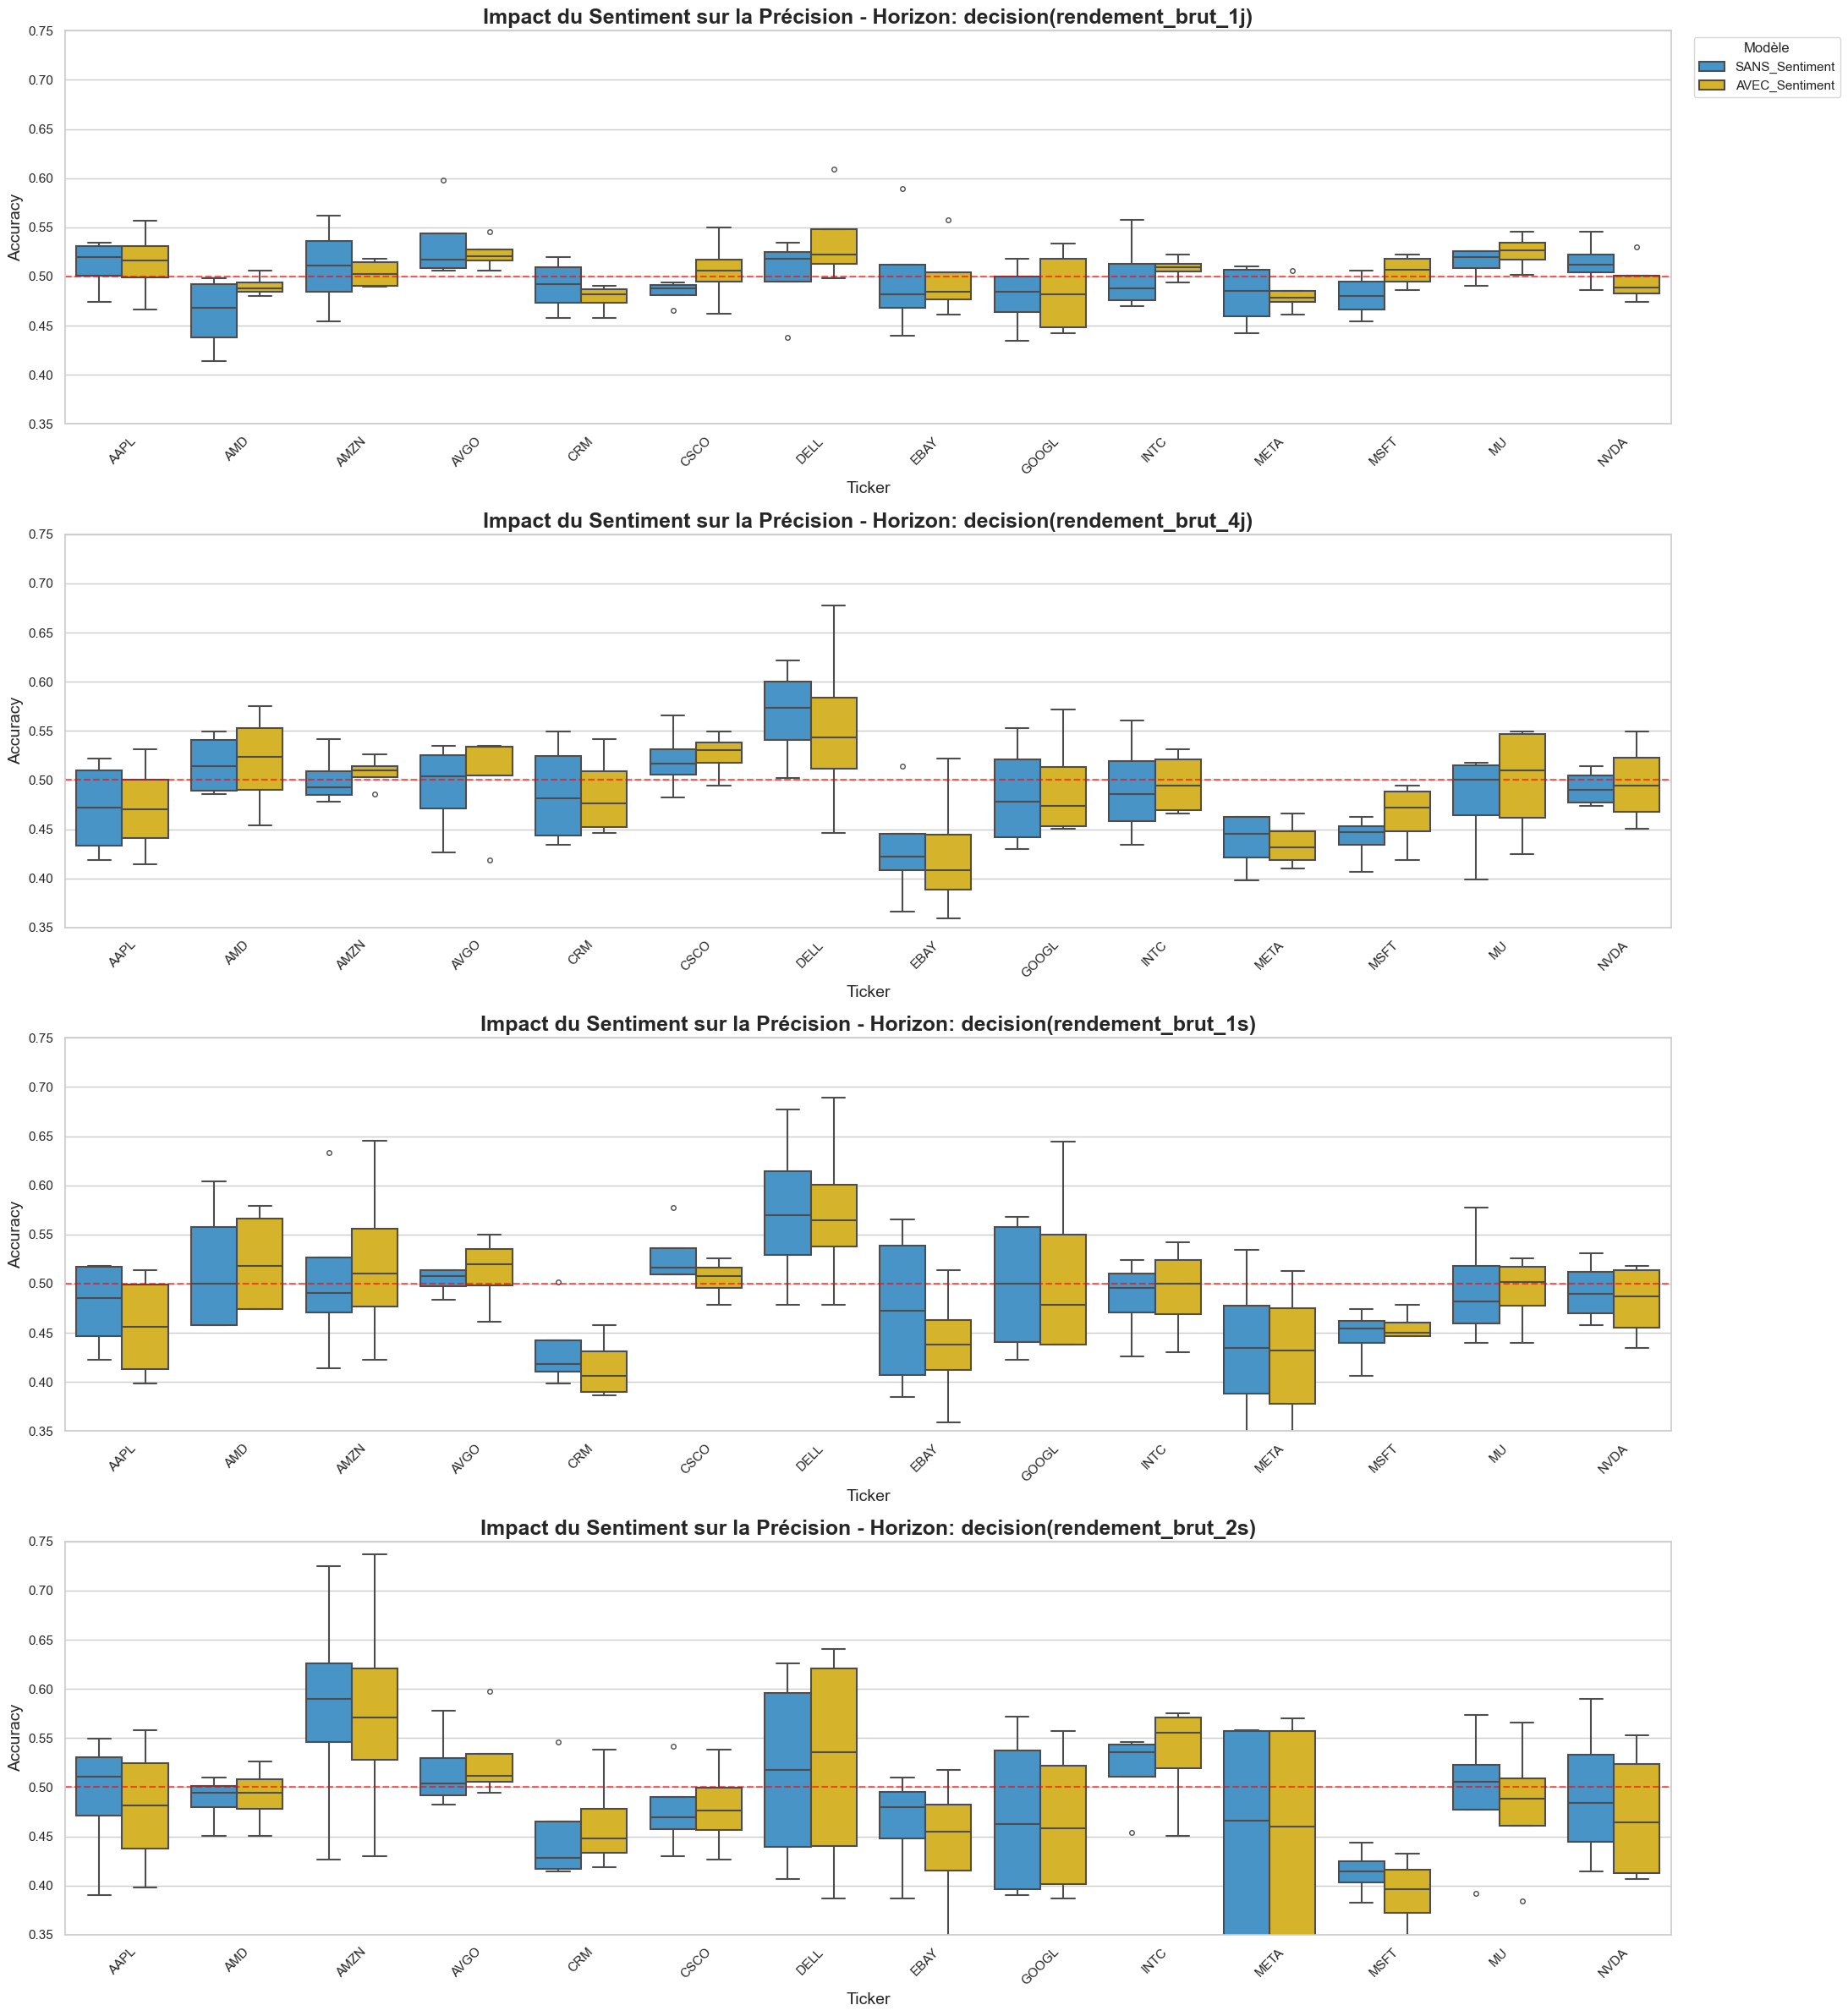

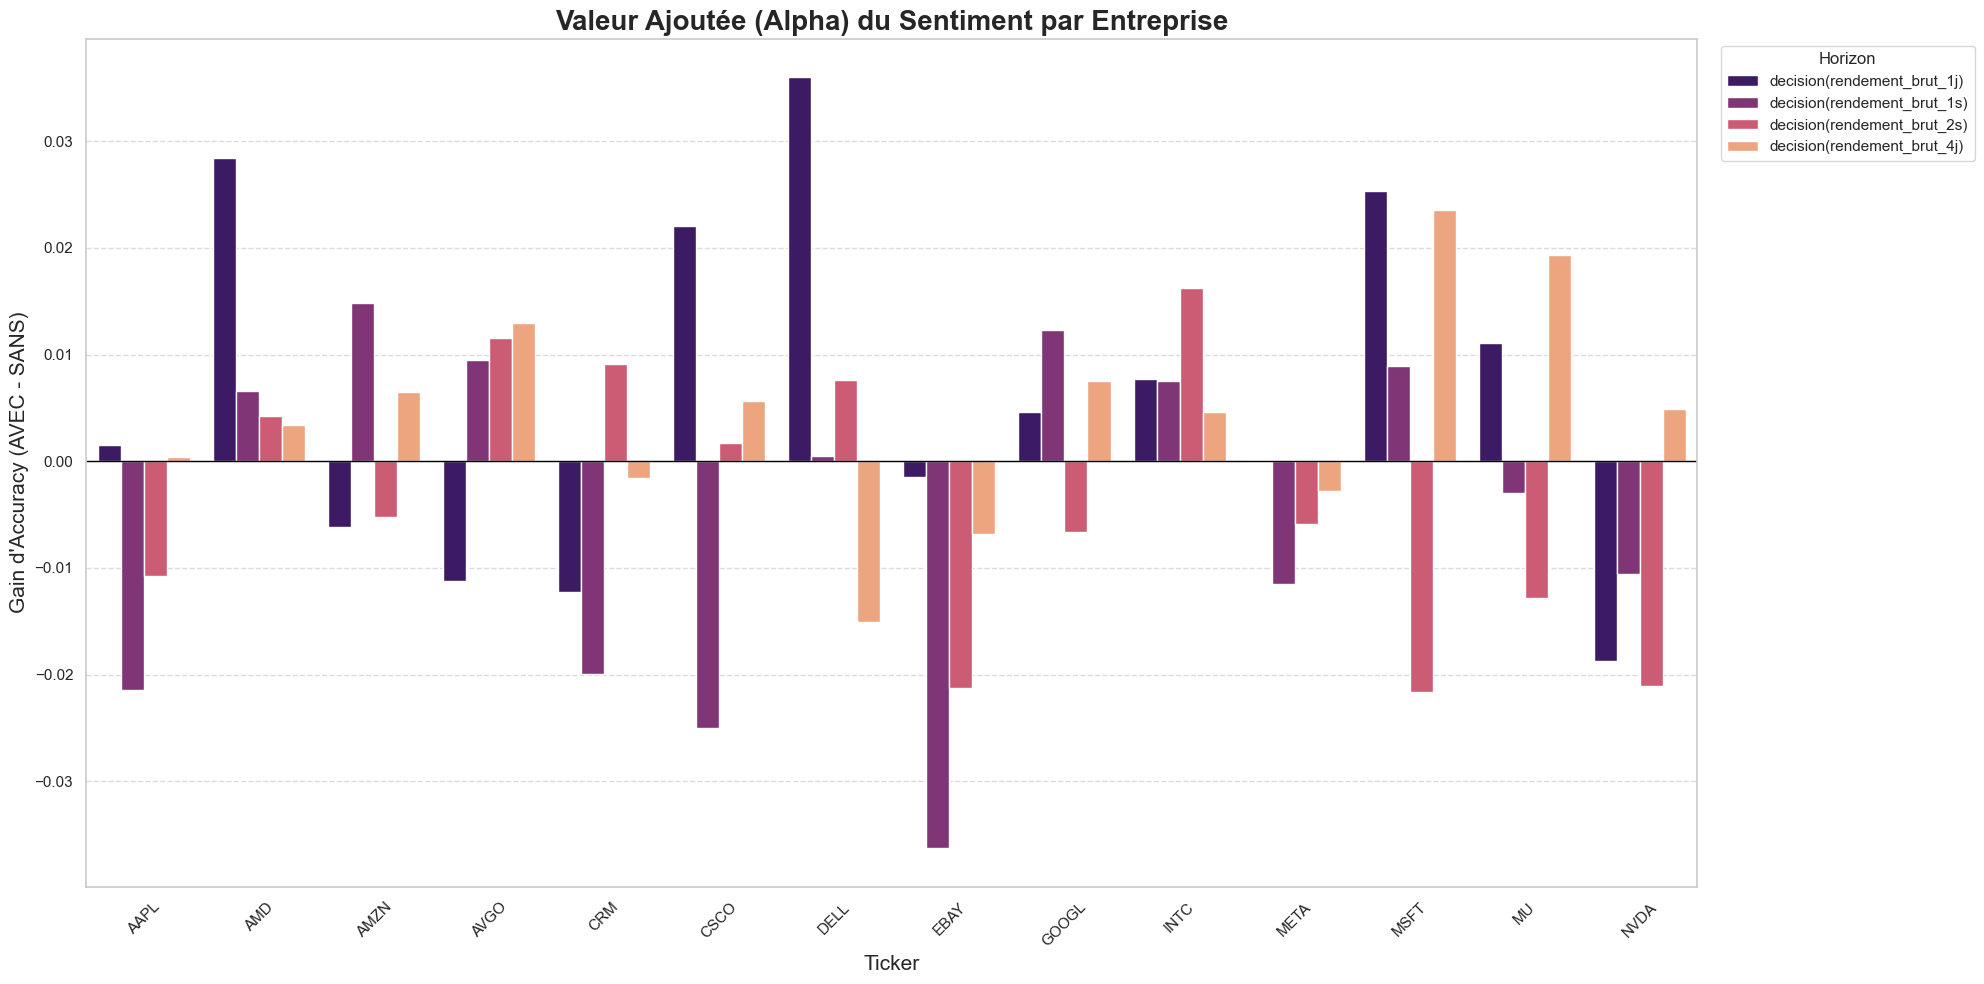

In [8]:
# Configuration du style
sns.set_theme(style="whitegrid")
horizons = results_df['Decision_Target'].unique()

# ==========================================================
# VISUALISATION 1 : BOXPLOTS COMPARATIFS (4 HORIZONS)
# ==========================================================
fig, axes = plt.subplots(nrows=len(horizons), ncols=1, figsize=(22, 6 * len(horizons)))

for i, horizon in enumerate(horizons):
    data_plot = results_df[results_df['Decision_Target'] == horizon]
    
    sns.boxplot(
        data=data_plot,
        x='Ticker',
        y='Accuracy',
        hue='Configuration',
        palette={'SANS_Sentiment': '#3498db', 'AVEC_Sentiment': '#f1c40f'}, # Bleu vs Jaune
        ax=axes[i],
        linewidth=1.5,
        fliersize=4
    )
    
    axes[i].axhline(y=0.5, color='red', linestyle='--', alpha=0.6)
    axes[i].set_title(f"Impact du Sentiment sur la Précision - Horizon: {horizon}", fontsize=18, fontweight='bold')
    axes[i].set_ylabel("Accuracy", fontsize=14)
    axes[i].set_xlabel("Ticker", fontsize=14)
    axes[i].set_ylim(0.35, 0.75)
    axes[i].tick_params(axis='x', rotation=45)
    
    if i == 0:
        axes[i].legend(title="Modèle", bbox_to_anchor=(1.01, 1), loc='upper left')
    else:
        axes[i].get_legend().remove()

plt.tight_layout()
plt.show()

# ==========================================================
# VISUALISATION 2 : GAIN NET (ALPHA) PAR TICKER
# ==========================================================
# On prépare les données du gain net
gain_data = summary.reset_index()

plt.figure(figsize=(20, 10))
sns.barplot(
    data=gain_data,
    x='Ticker',
    y='Gain_Net',
    hue='Decision_Target',
    palette="magma"
)

plt.axhline(y=0, color='black', linestyle='-', linewidth=1)
plt.title("Valeur Ajoutée (Alpha) du Sentiment par Entreprise", fontsize=20, fontweight='bold')
plt.ylabel("Gain d'Accuracy (AVEC - SANS)", fontsize=15)
plt.xlabel("Ticker", fontsize=15)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title="Horizon", bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()

### Analyse de l'Impact du Sentiment avec FinBERT (2022-2026)

Cette section compare les performances du modèle SANS_Sentiment (Technique pure) et du modèle AVEC_Sentiment (Hybride : Technique + Sentiment Score + Sentiment Trend) sur la période où les news sont disponibles pour les entreprises avec au moins 400 jours où des articles sont disponibles.
#### 1. Constat Global : Un gain marginal

Les résultats montrent que pour la majorité des actifs, l'ajout du sentiment ne produit pas le "bond" d'accuracy espéré. Le gain net oscille généralement entre -0.5% et +0.5%.

* Pour certaine entreprise et dans certain cas l'information textuelle peut, dans certains cas précis, stabiliser la prédiction technique.

* Pour d'autre le sentiment semble introduire du bruit plutôt qu'une direction claire.

#### 2. Analyse des limites

##### A. La rareté du signal (contrainte API)

Nous sommes limités à un maximum de 2 articles par jour avec des jours sans aucune news.

* En finance quantitative, pour qu'un sentiment soit prédictif, il faut soit une masse critique (des centaines d'articles pour capter une "humeur"), soit une exclusivité totale.

* Avec 2 articles, si ces derniers ne traitent pas d'un événement majeur (Earnings, fusion-acquisition), le modèle reçoit un signal "faible" qui est noyé dans les variations massives du carnet d'ordres.

##### B. L'Efficience du Marché et la Latence

Le prix court plus vite que le texte.

* Arbitrage institutionnel : Les hedge funds utilisent des algorithmes de NLP (Natural Language Processing) ultra-rapides branchés directement sur les flux Reuters/Bloomberg. L'impact d'une news est absorbé par le prix en quelques millisecondes.

* Notre contrainte : Puisque nous travaillons sur des données de clôture journalières, au moment où notre modèle "lit" le sentiment de la journée, le marché a déjà corrigé le prix depuis plusieurs heures. Le sentiment devient alors un indicateur retardé plutôt qu'avancé.